In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

In [2]:
train_data = pd.read_csv("mnist_train.csv")
test_data = pd.read_csv("mnist_test.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (60000, 785)
Testing data shape: (10000, 785)


In [3]:
X_train = train_data.drop("label", axis=1)
y_train = train_data["label"]

In [4]:
X_test = test_data.drop("label", axis=1)
y_test = test_data["label"]

In [5]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

In [8]:
print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN testing shape: (10000, 28, 28, 1)


In [9]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Encoded labels:", y_train_cat.shape)

Encoded labels: (60000, 10)


In [10]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10
)

datagen.fit(X_train_cnn)

In [11]:
cnn = Sequential([

    # First Convolution Block
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Second Convolution Block
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Third Convolution Layer
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),


    # Flatten
    Flatten(),


    # Fully Connected Layer
    Dense(
        128,
        activation="relu"
    ),

    # Dropout
    Dropout(0.5),


    # Output Layer
    Dense(
        10,
        activation="softmax"
    )
])

C:\Users\GAYATRI PAGARE\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose = 1
)

In [15]:
history_cnn = cnn.fit(

    datagen.flow(
        X_train_cnn,
        y_train_cat,
        batch_size=64
    ),

    epochs=20,

    validation_data=(
        X_test_cnn,
        y_test_cat
    ),

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 74s 73ms/step - accuracy: 0.8819 - loss: 0.3742 - val_accuracy: 0.9872 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 75ms/step - accuracy: 0.9649 - loss: 0.1196 - val_accuracy: 0.9799 - val_loss: 0.0649 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9736 - loss: 0.0916 - val_accuracy: 0.9920 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9792 - loss: 0.0725 - val_accuracy: 0.9918 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 72ms/step - accuracy: 0.9821 - loss: 0.0637 - val_accuracy: 0.9937 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9832 - loss: 0.0583 - val_accuracy: 0.9927 - val_loss: 0.0246 - learning_rate: 0.0010
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.9849 - l

In [16]:
test_loss, test_accuracy = cnn.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9945 - loss: 0.0182

Test Loss: 0.01823524944484234
Test Accuracy: 0.9944999814033508


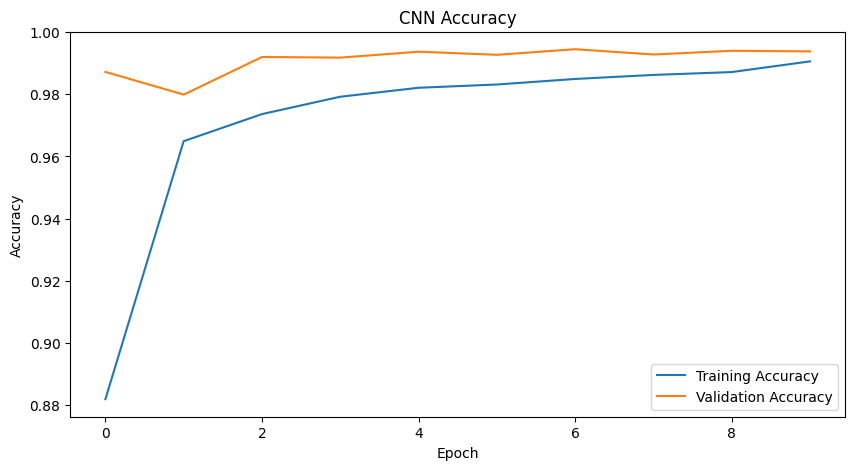

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

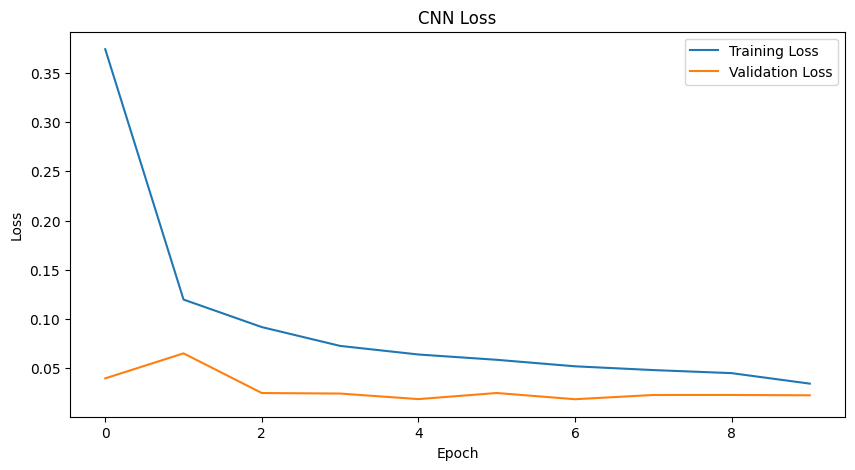

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
predictions = cnn.predict(
    X_test_cnn,
    verbose=1
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("First 10 predictions:")
print(predicted_labels[:10])

print("\nActual labels:")
print(y_test.values[:10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
First 10 predictions:
[7 2 1 0 4 1 4 9 5 9]

Actual labels:
[7 2 1 0 4 1 4 9 5 9]


In [20]:
cnn.save(
    "mnist_cnn_improved.keras"
)

print("\nModel saved successfully!")
print("File: mnist_cnn_improved.keras")


Model saved successfully!
File: mnist_cnn_improved.keras
